In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import re

In [2]:
# Define all subdirectories in ryddet
ryddet_base = Path('ryddet')

subdirs = {
    'base_linux': ryddet_base / 'base_linux',
    'base_unikernel': ryddet_base / 'base_unikernel',
    'optimized_linux_iso_eist_c-state_off': ryddet_base / 'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off': ryddet_base / 'optimized_linux_wo_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_on': ryddet_base / 'optimized_linux_wo_iso_eist_c-state_on',
    'optimized_unikernel': ryddet_base / 'otimized_unikernel',  # Note: typo in directory name
}

print("Available subdirectories:")
for name, path in subdirs.items():
    print(f"  {name}: {path}")

Available subdirectories:
  base_linux: ryddet/base_linux
  base_unikernel: ryddet/base_unikernel
  optimized_linux_iso_eist_c-state_off: ryddet/optimized_linux_iso_eist_c-state_off
  optimized_linux_wo_iso_eist_c-state_off: ryddet/optimized_linux_wo_iso_eist_c-state_off
  optimized_linux_wo_iso_eist_c-state_on: ryddet/optimized_linux_wo_iso_eist_c-state_on
  optimized_unikernel: ryddet/otimized_unikernel


In [3]:
# Load powermeter measurements (binary_output_*.log files)
powermeter_data = {}

for name, path in subdirs.items():
    powermeter_data[name] = {}
    
    # Get all .log files in the directory
    log_files = sorted(path.glob('binary_output_*.log'))
    
    for log_file in log_files:
        # Extract benchmark name and iteration number from filename
        # e.g., binary_output_crc32_0.log -> benchmark=crc32, iteration=0
        match = re.match(r'binary_output_(.+)_(\d+)\.log', log_file.name)
        if match:
            benchmark = match.group(1)
            iteration = int(match.group(2))
            
            # Initialize benchmark dict if needed
            if benchmark not in powermeter_data[name]:
                powermeter_data[name][benchmark] = {}
            
            # Load the log file
            try:
                df = pd.read_csv(log_file)
                powermeter_data[name][benchmark][iteration] = df
            except Exception as e:
                print(f"Error loading {log_file}: {e}")

# Print summary
print("Powermeter data summary:")
for config_name, benchmarks in powermeter_data.items():
    total_files = sum(len(iterations) for iterations in benchmarks.values())
    print(f"  {config_name}: {len(benchmarks)} benchmarks, {total_files} total files")

Error loading ryddet/optimized_linux_wo_iso_eist_c-state_off/binary_output_cubic_5.log: No columns to parse from file
Error loading ryddet/otimized_unikernel/binary_output_crc32_1.log: No columns to parse from file
Error loading ryddet/otimized_unikernel/binary_output_cubic_10.log: No columns to parse from file
Powermeter data summary:
  base_linux: 9 benchmarks, 450 total files
  base_unikernel: 9 benchmarks, 450 total files
  optimized_linux_iso_eist_c-state_off: 9 benchmarks, 450 total files
  optimized_linux_wo_iso_eist_c-state_off: 9 benchmarks, 449 total files
  optimized_linux_wo_iso_eist_c-state_on: 9 benchmarks, 450 total files
  optimized_unikernel: 9 benchmarks, 448 total files


In [4]:
# Display sample powermeter data
config = 'base_linux'
benchmark = 'crc32'
iteration = 0

if config in powermeter_data and benchmark in powermeter_data[config]:
    if iteration in powermeter_data[config][benchmark]:
        print(f"Sample powermeter data from {config} / {benchmark} / iteration {iteration}:")
        print(powermeter_data[config][benchmark][iteration].head(10))
        print(f"\nShape: {powermeter_data[config][benchmark][iteration].shape}")
    else:
        print(f"Iteration {iteration} not found")
else:
    print(f"Config or benchmark not found")

Sample powermeter data from base_linux / crc32 / iteration 0:
     unix_timestamp  active_power (mW)
0  1769679226797480              49380
1  1769679226840548              30650
2  1769679226883642              47620
3  1769679226926374              45280
4  1769679226969460              44590
5  1769679227012621              44700
6  1769679227055736              44710
7  1769679227100474              44770
8  1769679227143607              44910
9  1769679227186615              44770

Shape: (393, 2)


In [5]:
# Display structure of powermeter data
print("Benchmarks found per configuration:")
for config_name, benchmarks in powermeter_data.items():
    benchmark_list = sorted(benchmarks.keys())
    iterations = [len(benchmarks[b]) for b in benchmark_list]
    print(f"\n{config_name}:")
    print(f"  Benchmarks: {benchmark_list}")
    print(f"  Iterations per benchmark: {iterations[0] if iterations else 0} (first benchmark)")

Benchmarks found per configuration:

base_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

base_unikernel:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_iso_eist_c-state_off:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_wo_iso_eist_c-state_off:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_wo_iso_eist_c-state_on:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iteration

In [6]:
# Load PC measurements (unikernel_output.csv from each directory)
pc_data = {}

for name, path in subdirs.items():
    csv_file = path / 'unikernel_output.csv'
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        pc_data[name] = df
        print(f"Loaded {name}: {len(df)} rows, {len(df.columns)} columns")
    else:
        print(f"Warning: {csv_file} not found")

print(f"\nTotal configurations loaded: {len(pc_data)}")

Loaded base_linux: 450 rows, 21 columns
Loaded base_unikernel: 450 rows, 21 columns
Loaded optimized_linux_iso_eist_c-state_off: 450 rows, 21 columns
Loaded optimized_linux_wo_iso_eist_c-state_off: 450 rows, 21 columns
Loaded optimized_linux_wo_iso_eist_c-state_on: 450 rows, 21 columns
Loaded optimized_unikernel: 451 rows, 21 columns

Total configurations loaded: 6


In [7]:
# Display sample PC data for one configuration
print("Sample PC data from base_linux:")
print(pc_data['base_linux'].head())

Sample PC data from base_linux:
  benchmark   cpu_cycles   cycles_start     cycles_end       time_ns  \
0     crc32  52264844388  2744974811597  2797239655985  1.689800e+10   
1     crc32  52260900301  2797240059066  2849500959367  1.689672e+10   
2     crc32  52272654002  2849501249129  2901773903131  1.690052e+10   
3     crc32  52263599416  2901774319665  2954037919081  1.689759e+10   
4     crc32  52271811460  2954038206271  3006310017731  1.690024e+10   

        time_ms  cooldown_ms  temp_before  temp_after  pkg_temp_before  ...  \
0  16898.003169       20.288         45.0        43.0             45.0  ...   
1  16896.718633        0.010         43.0        43.0             43.0  ...   
2  16900.515695        0.009         43.0        44.0             43.0  ...   
3  16897.591201        0.009         44.0        44.0             44.0  ...   
4  16900.241563        0.009         44.0        44.0             44.0  ...   

   pkg_joules      pkg_mJ  pp0_joules      pp0_mJ  pp1_joule

In [8]:
# Calculate energy consumption from powermeter data and compare with pkg energy
# Energy = Average Power (W) × Time (s)

energy_results = []

for config_name in subdirs.keys():
    # Get PC data for this config
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    # Get unique benchmarks from PC data
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get PC measurements for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        # Calculate mean pkg energy from PC data (in Joules)
        mean_pkg_joules = pc_bench['pkg_joules'].mean()
        mean_time_ms = pc_bench['time_ms'].mean()
        
        # Calculate energy from powermeter data if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                # Skip empty or very small DataFrames (need at least 2 points for time span)
                if len(pm_df) < 2:
                    continue
                    
                # Calculate time span in seconds
                timestamps = pd.to_numeric(pm_df['unix_timestamp'], errors='coerce').values
                time_span_s = (timestamps[-1] - timestamps[0]) / 1e6  # Convert microseconds to seconds
                
                # Calculate average power in Watts (convert mW to W)
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                
                # Calculate energy in Joules
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            mean_powermeter_energy = np.mean(powermeter_energies) if powermeter_energies else None
        else:
            mean_powermeter_energy = None
        
        energy_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_energy_j': mean_pkg_joules,
            'powermeter_energy_j': mean_powermeter_energy,
            'time_ms': mean_time_ms
        })

# Convert to DataFrame for easier plotting
energy_df = pd.DataFrame(energy_results)
print(f"Energy analysis ready: {len(energy_df)} benchmark-config combinations")
print(energy_df.head(10))

Energy analysis ready: 55 benchmark-config combinations
           config      benchmark  pkg_energy_j  powermeter_energy_j  \
0      base_linux          crc32    328.745854           816.272421   
1      base_linux          cubic    303.501435           740.730307   
2      base_linux       dijkstra    364.126380           858.385031   
3      base_linux           fdct    292.324112           678.737752   
4      base_linux            fir    249.244443           586.581164   
5      base_linux  matmult-float    334.835891           738.634966   
6      base_linux    matmult-int    309.250208           707.391567   
7      base_linux  nettle-sha256    396.754678           814.384796   
8      base_linux       rijndael    338.380310           744.973681   
9  base_unikernel          crc32    264.171602           784.955112   

        time_ms  
0  17005.423499  
1  15642.933550  
2  17227.503788  
3  14067.986429  
4  12209.316186  
5  14963.958258  
6  14395.283947  
7  16329.042434  


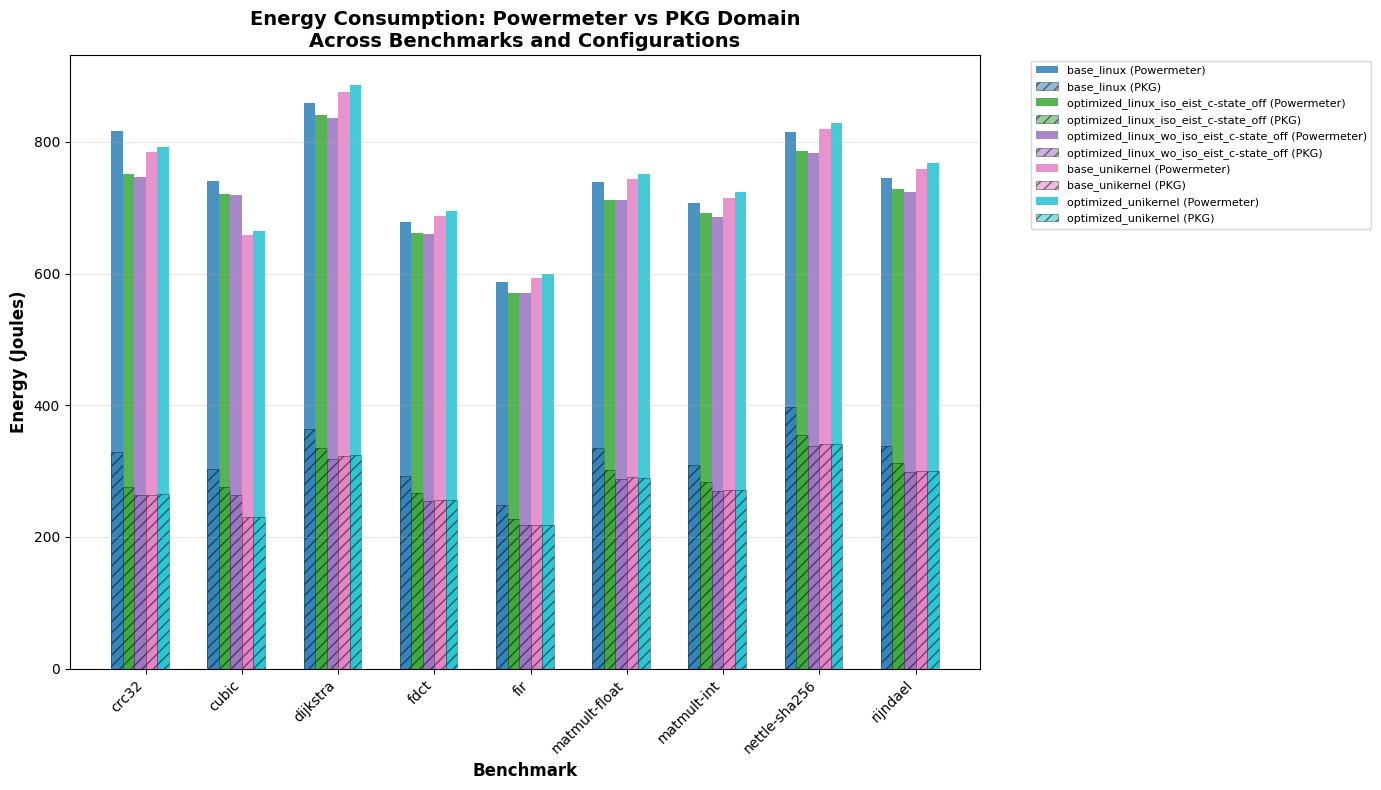

In [9]:
# Create plot comparing powermeter energy vs pkg energy for each benchmark
fig, ax = plt.subplots(figsize=(14, 8))

# Filter out specific configuration
plot_df = energy_df[energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

# Get unique benchmarks and configs (filter out NaN values)
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
# Filter to only configs present in data, maintaining the desired order
configs = [c for c in config_order if c in plot_df['config'].unique()]

# Set up x positions for grouped bars
x = np.arange(len(benchmarks))
width = 0.12  # Width of each bar
colors = plt.cm.tab10(np.linspace(0, 0.9, len(configs)))

# Plot bars for each configuration
for i, config in enumerate(configs):
    config_data = plot_df[plot_df['config'] == config]
    
    # Prepare data aligned with benchmark order
    pm_energies = []
    pkg_energies = []
    
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0:
            pm_energies.append(bench_data['powermeter_energy_j'].values[0])
            pkg_energies.append(bench_data['pkg_energy_j'].values[0])
        else:
            pm_energies.append(0)
            pkg_energies.append(0)
    
    # Plot powermeter energy (solid bars)
    offset = (i - len(configs)/2) * width
    ax.bar(x + offset, pm_energies, width, label=f'{config} (Powermeter)', 
           color=colors[i], alpha=0.8)
    
    # Plot pkg energy (hatched bars, same color)
    ax.bar(x + offset, pkg_energies, width, label=f'{config} (PKG)', 
           color=colors[i], alpha=0.5, hatch='///', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
ax.set_title('Energy Consumption: Powermeter vs PKG Domain\nAcross Benchmarks and Configurations', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(benchmarks, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Calculate coefficient of variation (CV) for energy measurements
# CV = (std / mean) * 100%

cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PKG energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pkg_energies = pc_bench['pkg_joules'].values
        
        # Calculate PKG CV
        if len(pkg_energies) > 1:
            pkg_cv = (pkg_energies.std() / pkg_energies.mean()) * 100
        else:
            pkg_cv = None
        
        # Calculate powermeter CV if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                timestamps = pd.to_numeric(pm_df['unix_timestamp'], errors='coerce').values
                time_span_s = (timestamps[-1] - timestamps[0]) / 1e6
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            if len(powermeter_energies) > 1:
                pm_cv = (np.std(powermeter_energies) / np.mean(powermeter_energies)) * 100
            else:
                pm_cv = None
        else:
            pm_cv = None
        
        cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_cv': pkg_cv,
            'powermeter_cv': pm_cv
        })

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)
print(f"CV analysis ready: {len(cv_df)} benchmark-config combinations")
print(cv_df.head(10))

CV analysis ready: 55 benchmark-config combinations
           config      benchmark     pkg_cv  powermeter_cv
0      base_linux          crc32  19.946672      17.814252
1      base_linux          cubic   0.090322       0.131564
2      base_linux       dijkstra   0.171615       0.150677
3      base_linux           fdct   0.578578       0.360824
4      base_linux            fir   0.059532       0.126204
5      base_linux  matmult-float   0.081293       0.159346
6      base_linux    matmult-int   0.571383       0.617735
7      base_linux  nettle-sha256   0.064466       0.130299
8      base_linux       rijndael   0.066406       0.126165
9  base_unikernel          crc32   0.205584       0.323300


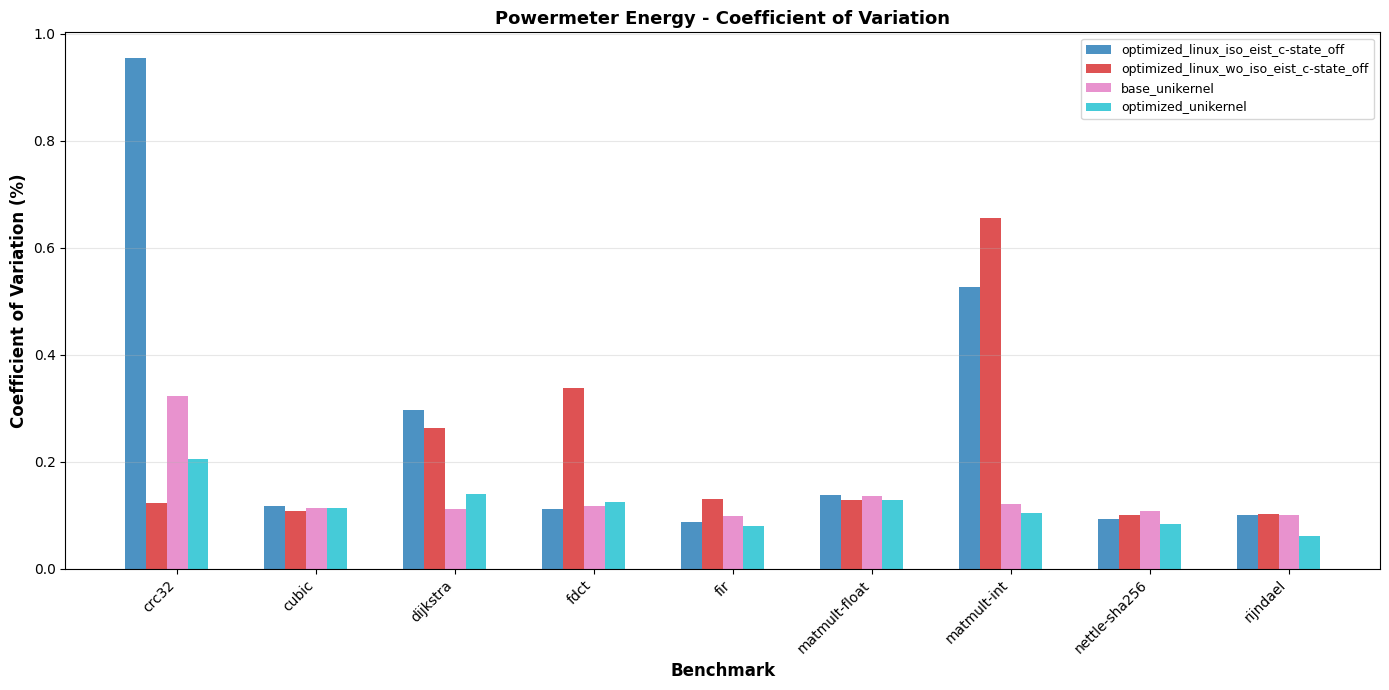

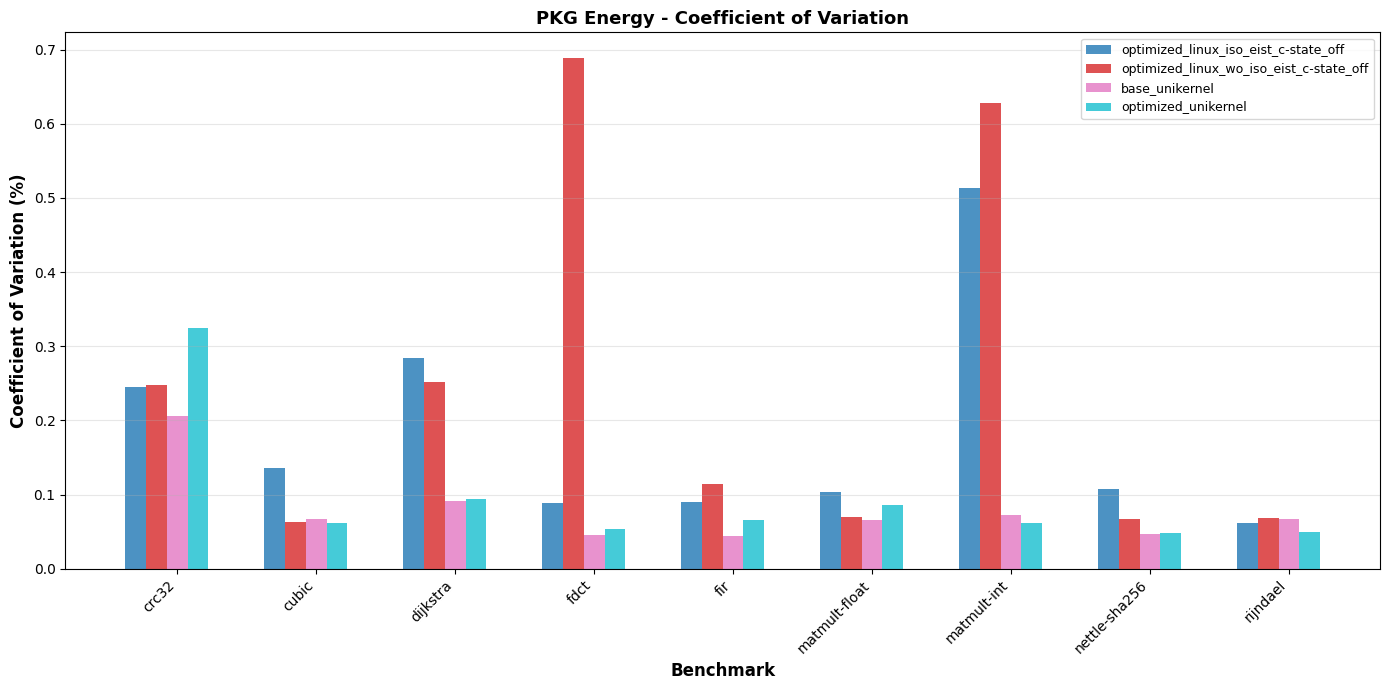

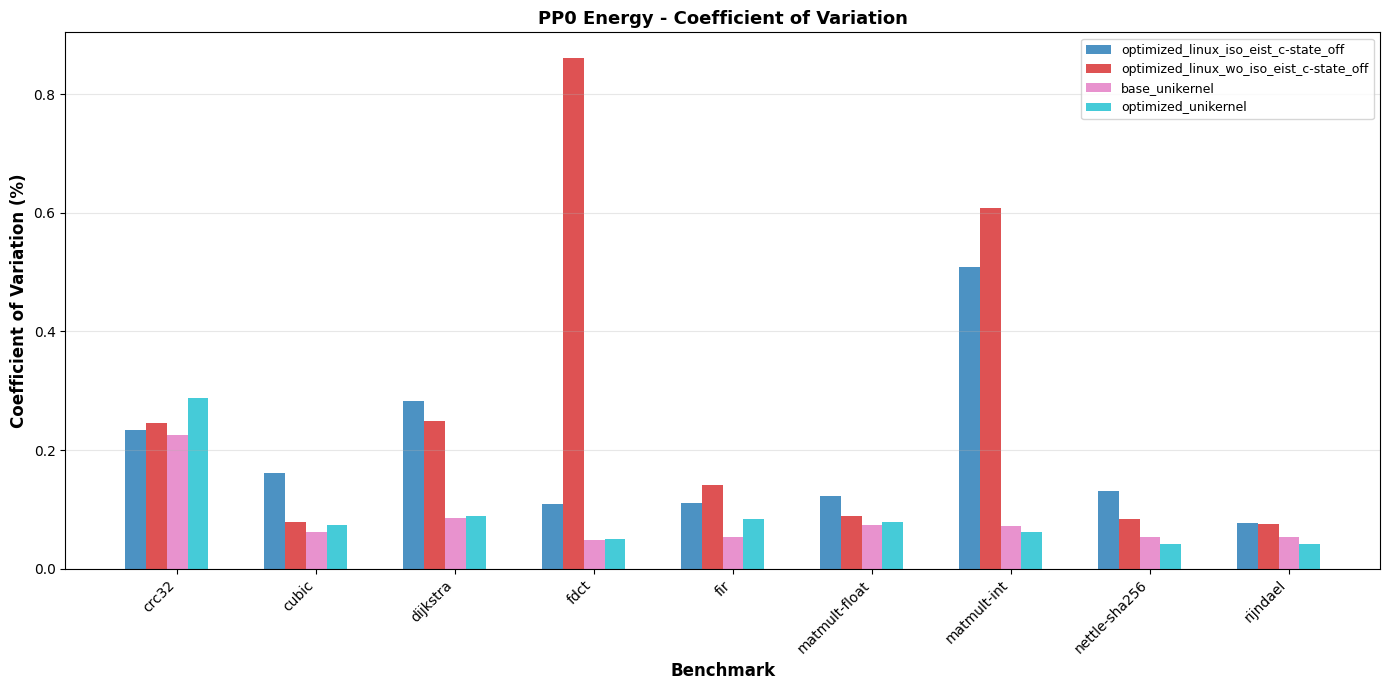

In [29]:
# Create three separate plots for coefficient of variation
# Filter out specific configuration
cv_plot_df = cv_df[cv_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

# Get unique benchmarks and configs
benchmarks = sorted([b for b in cv_plot_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    #'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in cv_plot_df['config'].unique()]

# Set up x positions
x = np.arange(len(benchmarks))
width = 0.15
colors = plt.cm.tab10(np.linspace(0, 0.9, len(configs)))

# Plot 1: Powermeter CV
fig1, ax1 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_plot_df[cv_plot_df['config'] == config]
    
    pm_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['powermeter_cv'].values[0]):
            pm_cvs.append(bench_data['powermeter_cv'].values[0])
        else:
            pm_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax1.bar(x + offset, pm_cvs, width, label=config, color=colors[i], alpha=0.8)

ax1.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax1.set_title('Powermeter Energy - Coefficient of Variation', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(benchmarks, rotation=45, ha='right')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: PKG CV
fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_plot_df[cv_plot_df['config'] == config]
    
    pkg_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pkg_cv'].values[0]):
            pkg_cvs.append(bench_data['pkg_cv'].values[0])
        else:
            pkg_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax2.bar(x + offset, pkg_cvs, width, label=config, color=colors[i], alpha=0.8)

ax2.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax2.set_title('PKG Energy - Coefficient of Variation', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(benchmarks, rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: PP0 CV
# Calculate PP0 CV results
pp0_cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PP0 energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pp0_energies = pc_bench['pp0_joules'].values
        
        # Calculate PP0 CV
        if len(pp0_energies) > 1:
            pp0_cv = (pp0_energies.std() / pp0_energies.mean()) * 100
        else:
            pp0_cv = None
        
        pp0_cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pp0_cv': pp0_cv
        })

# Convert to DataFrame
pp0_cv_df = pd.DataFrame(pp0_cv_results)

# Filter out specific configuration
pp0_cv_plot_df = pp0_cv_df[pp0_cv_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

fig3, ax3 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = pp0_cv_plot_df[pp0_cv_plot_df['config'] == config]
    
    pp0_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pp0_cv'].values[0]):
            pp0_cvs.append(bench_data['pp0_cv'].values[0])
        else:
            pp0_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax3.bar(x + offset, pp0_cvs, width, label=config, color=colors[i], alpha=0.8)

ax3.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax3.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax3.set_title('PP0 Energy - Coefficient of Variation', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(benchmarks, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


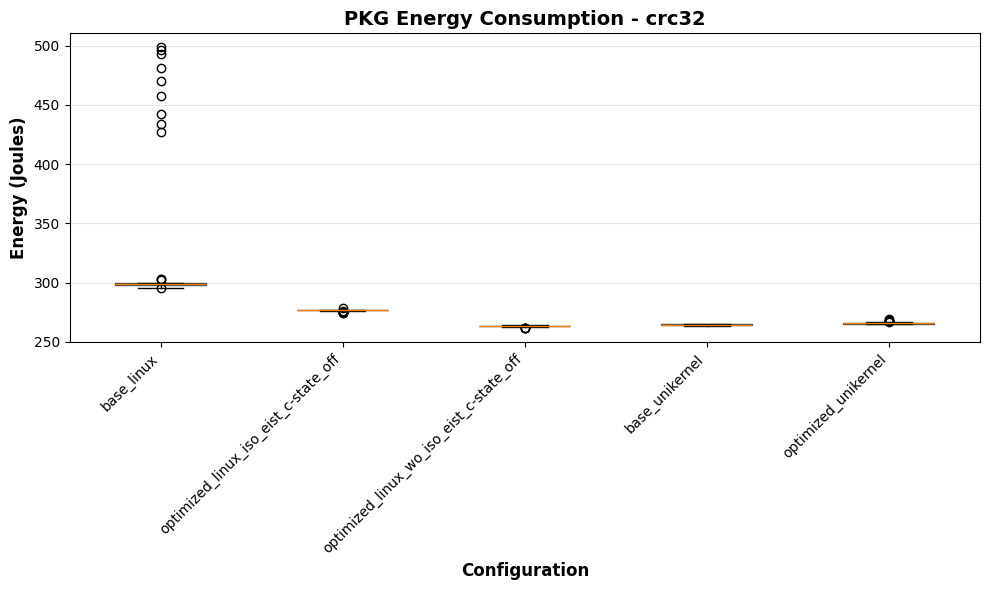

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


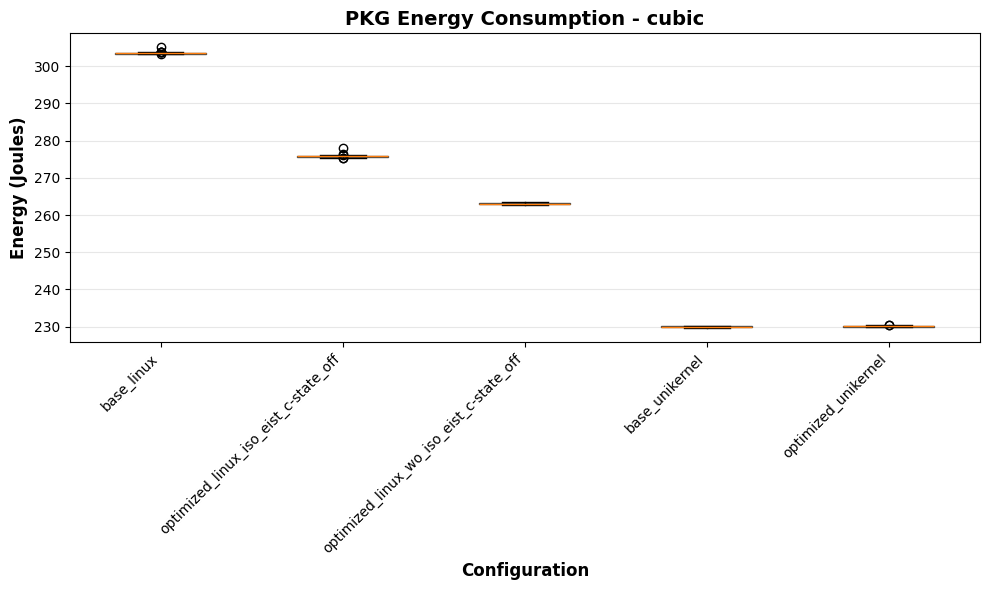

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


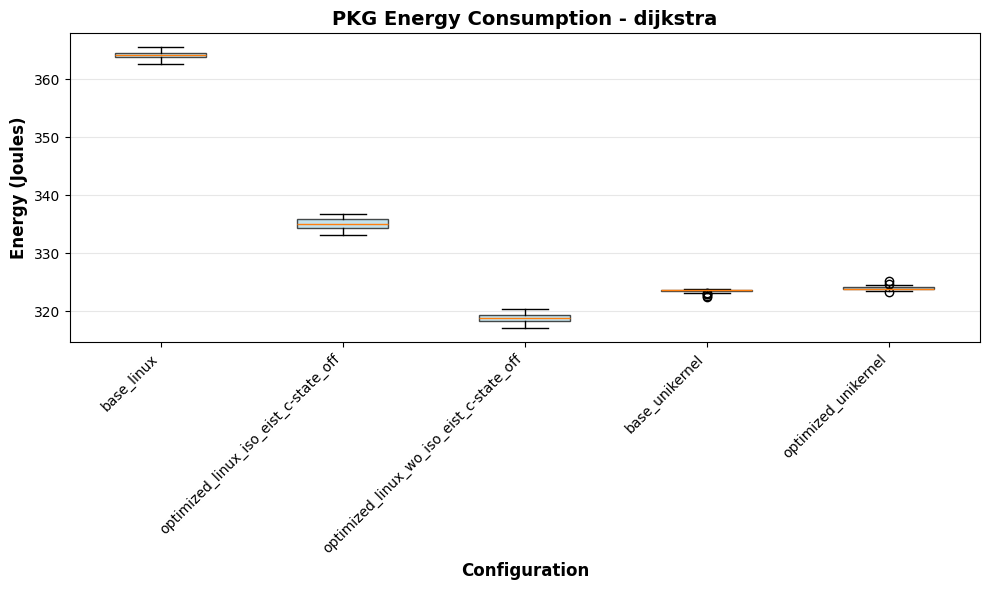

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


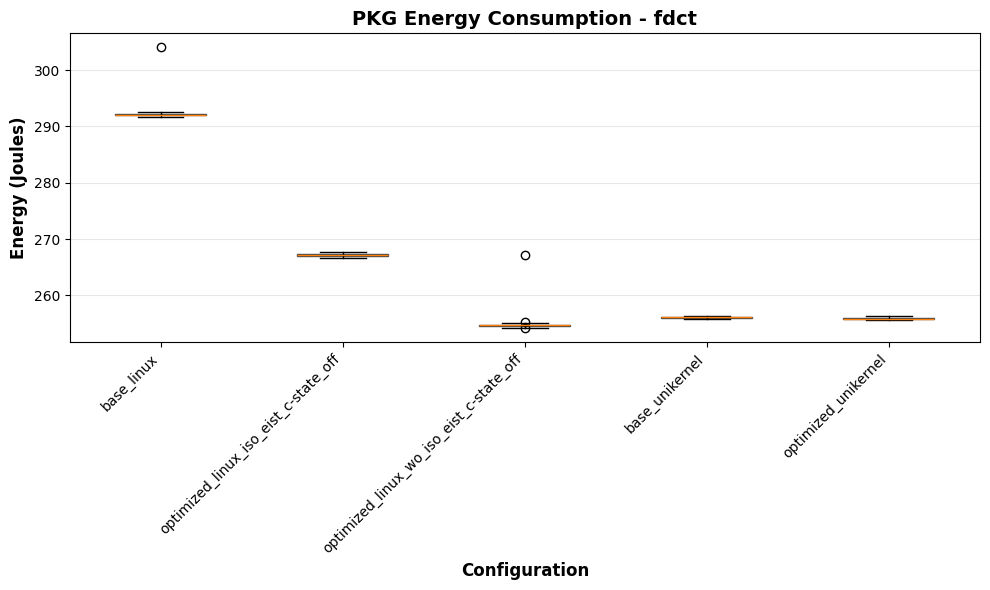

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


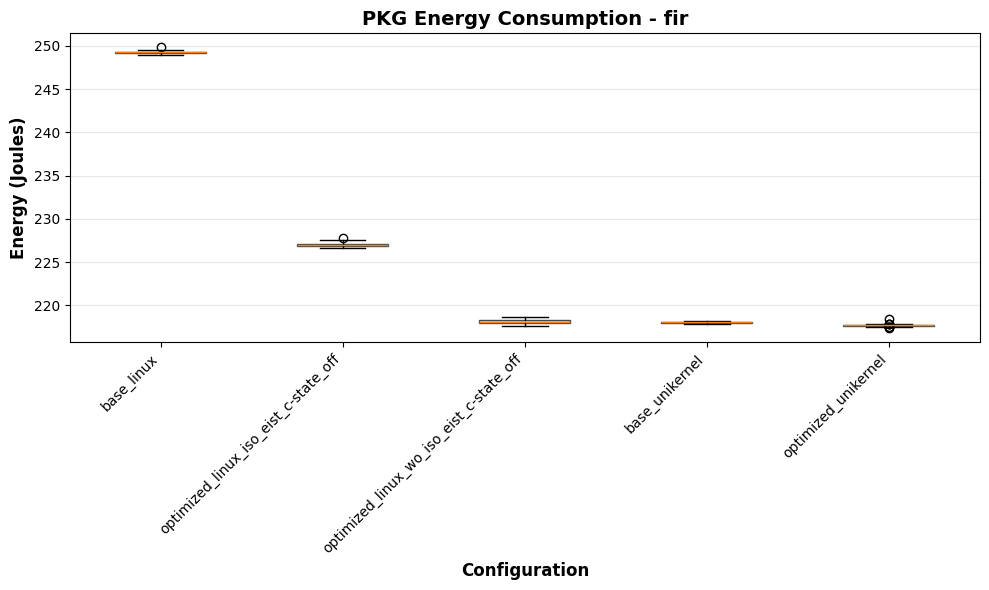

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


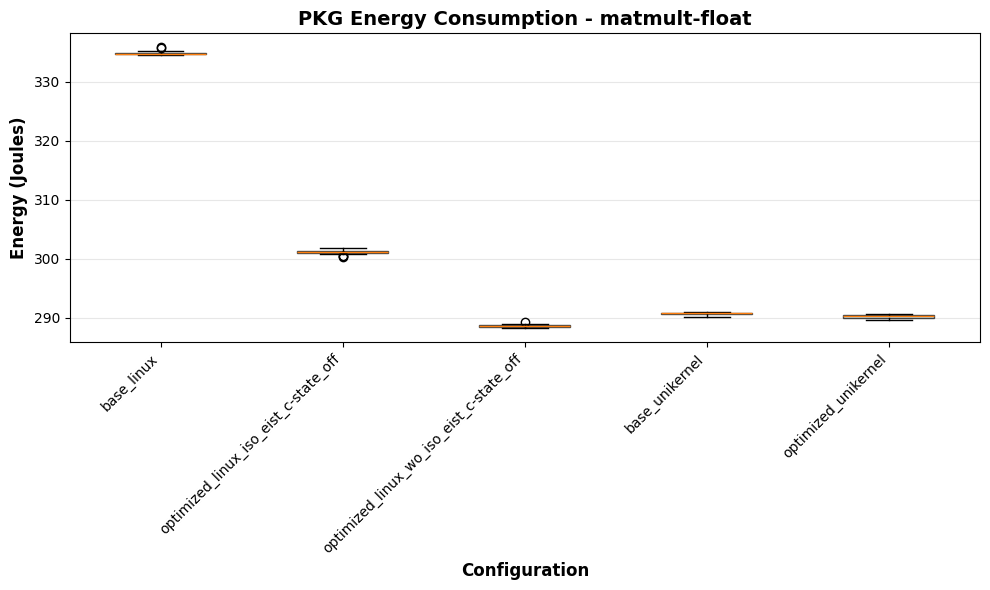

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


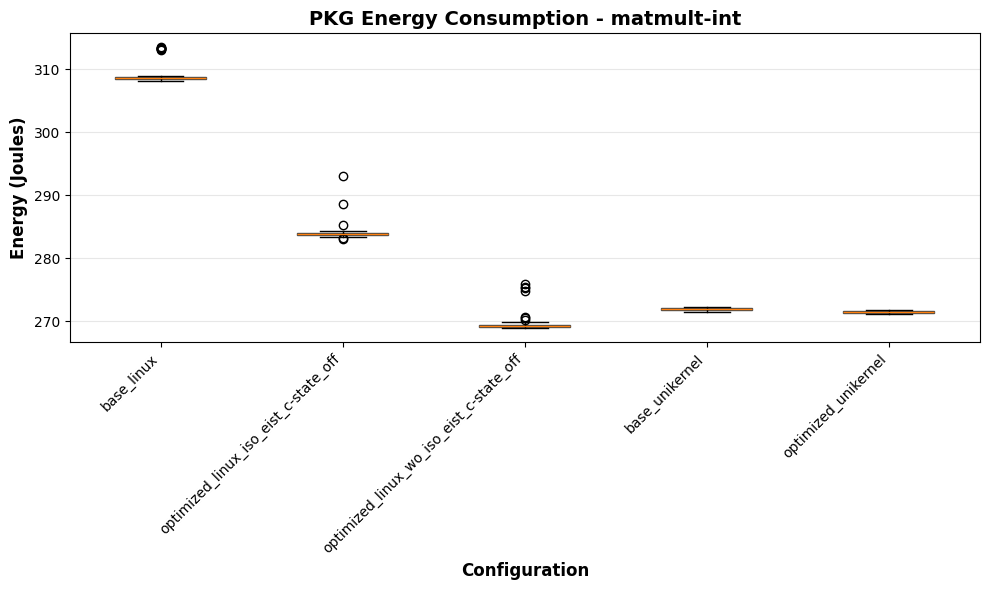

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


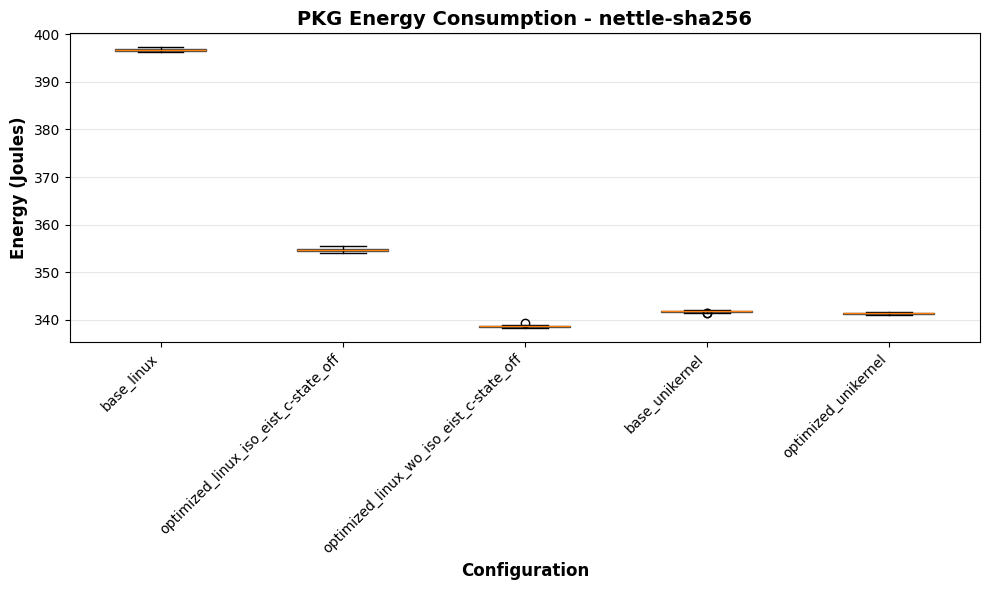

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2503486210.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


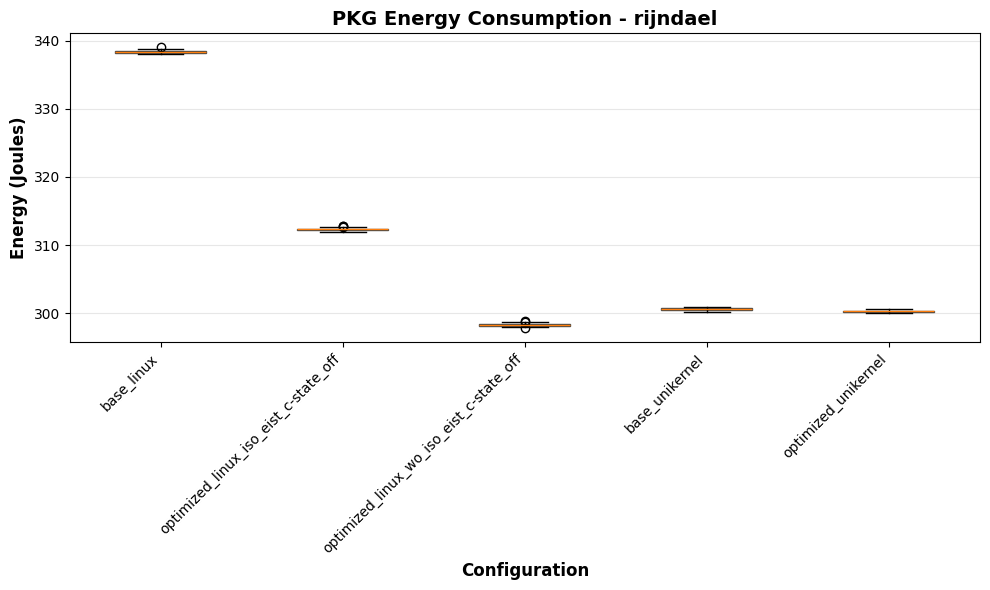

In [ ]:
# Boxplot for PKG energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pkg_joules'].values)
            labels.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PKG Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


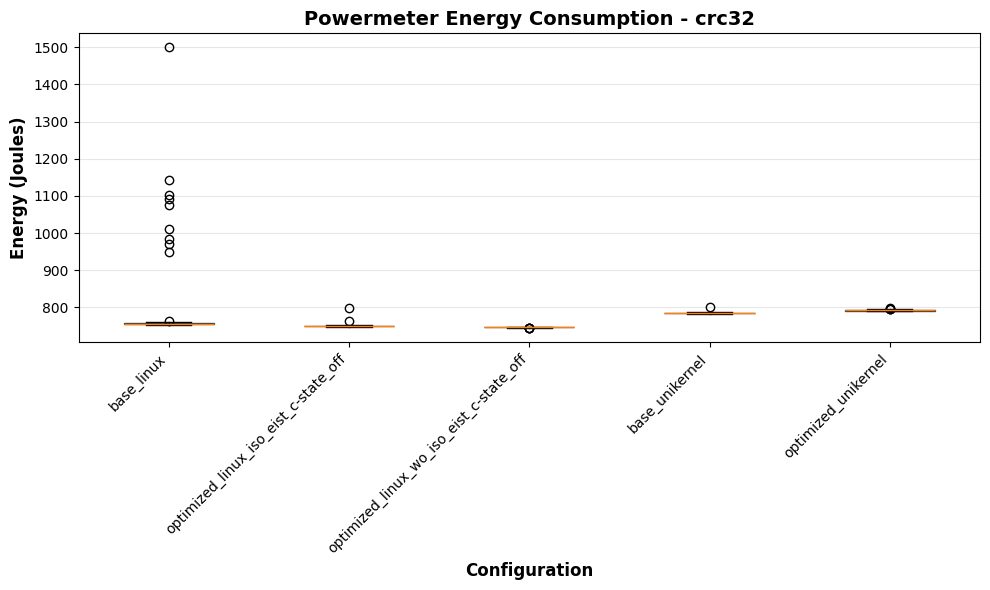

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


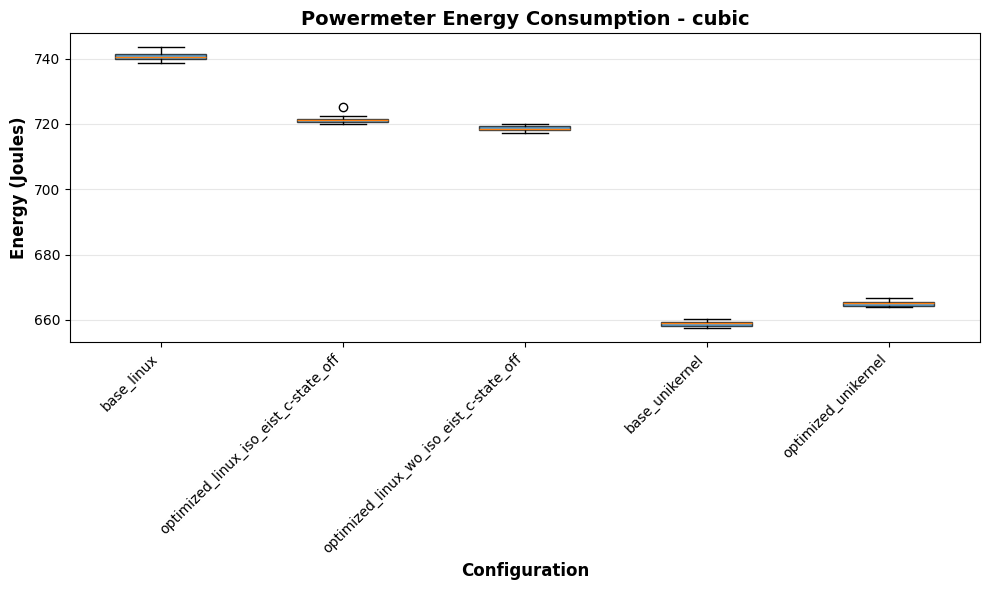

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


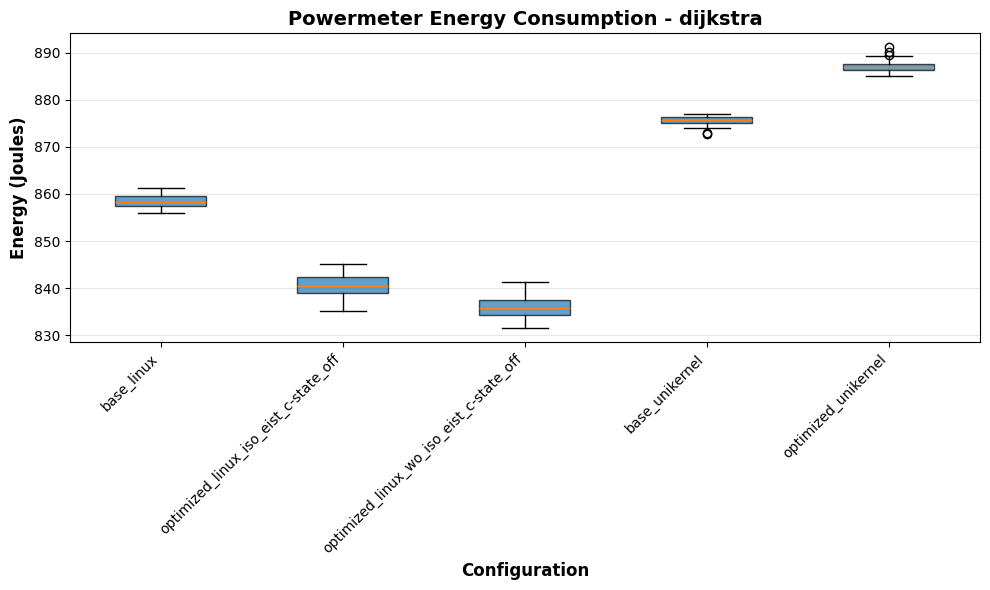

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


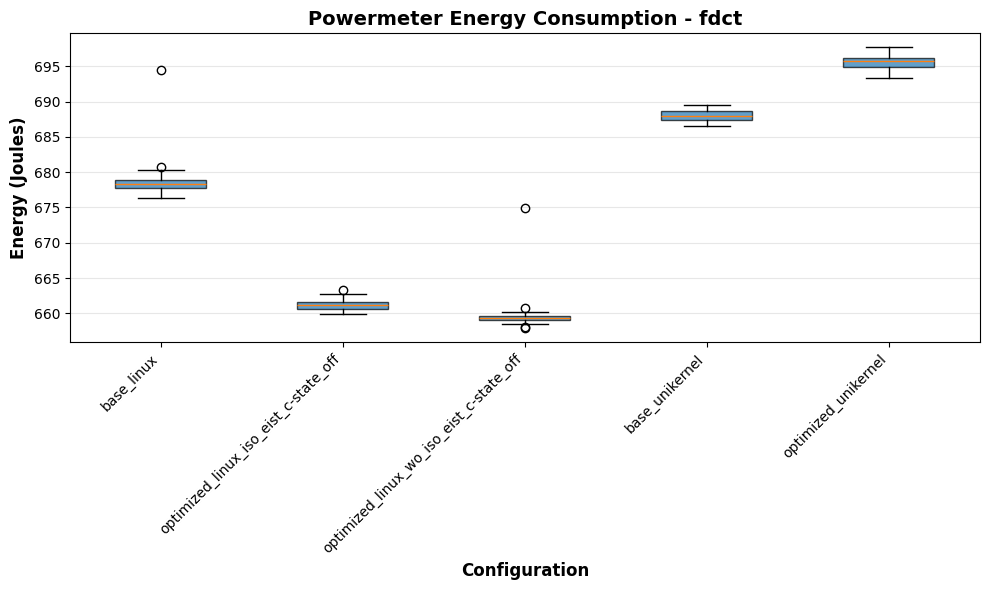

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


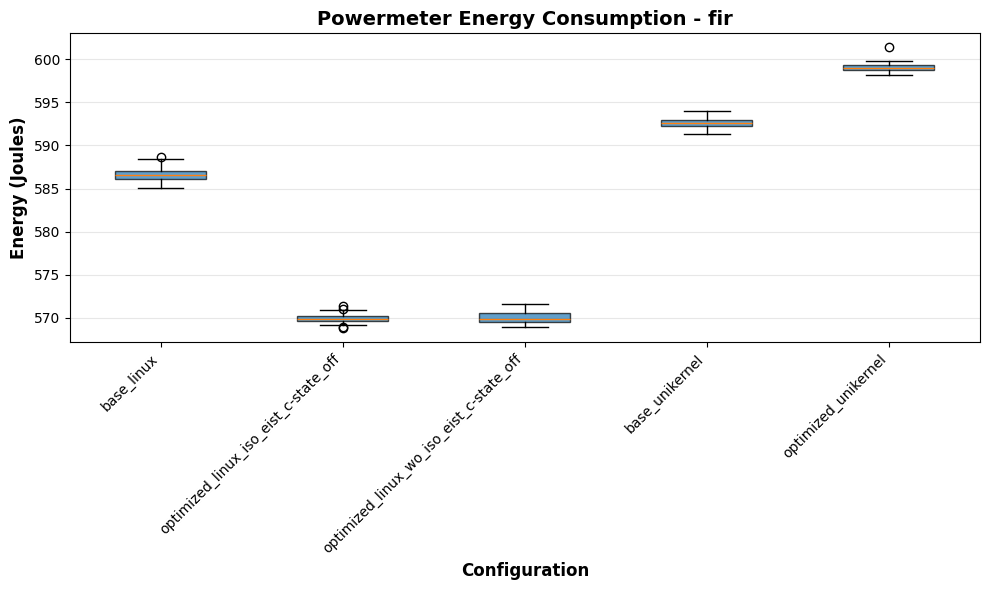

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


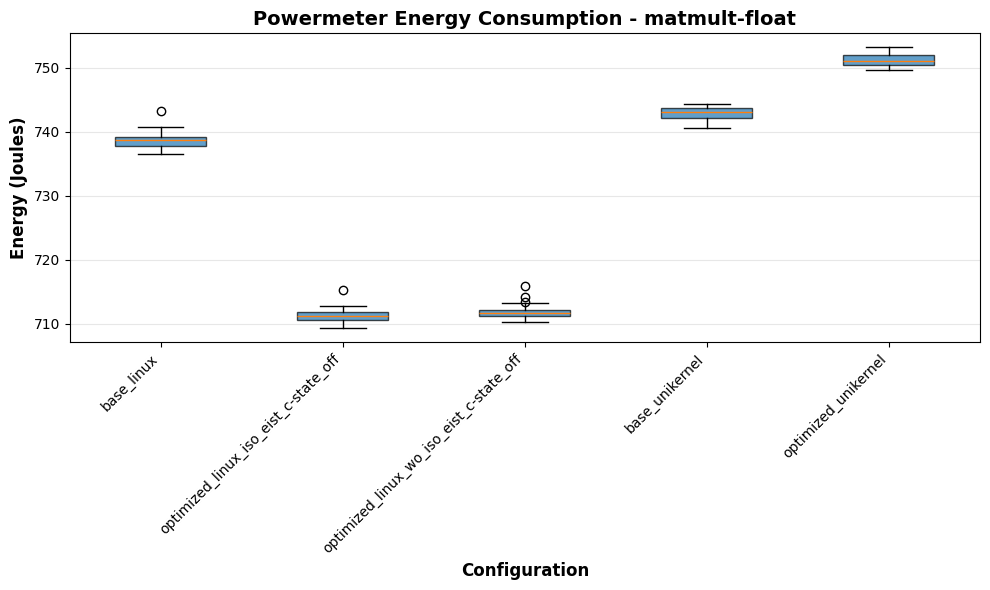

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


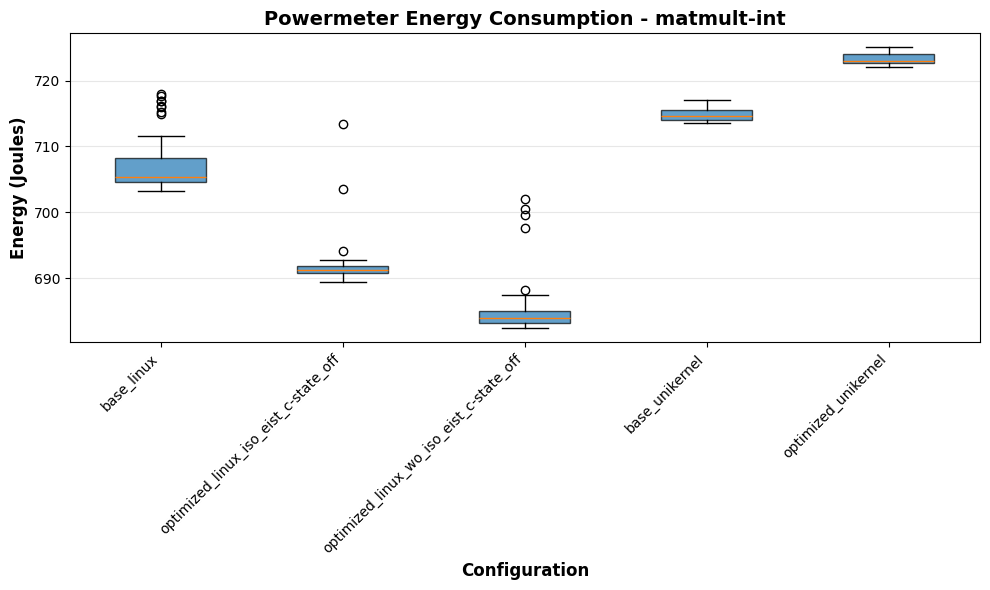

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


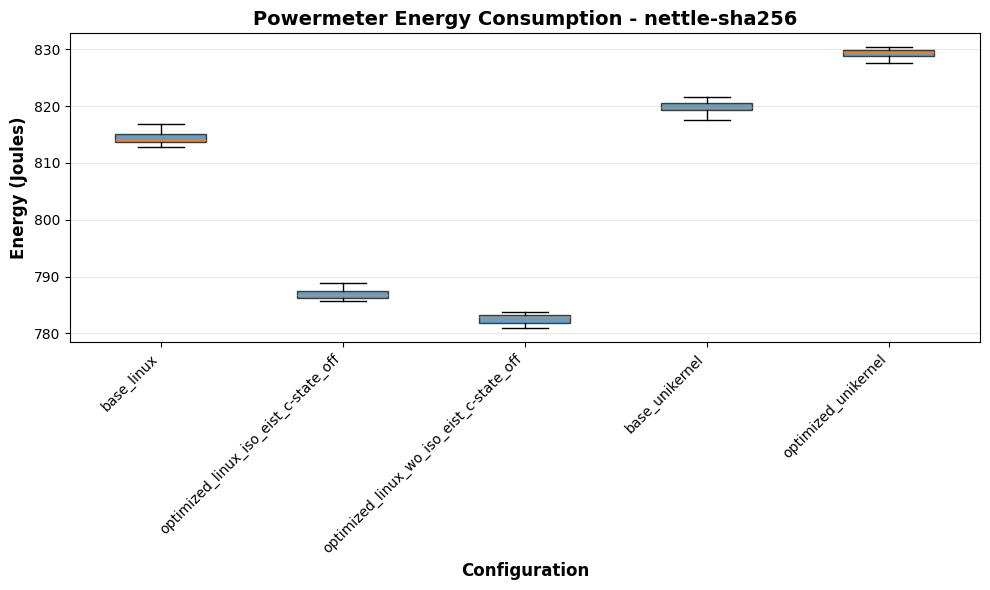

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2068264680.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


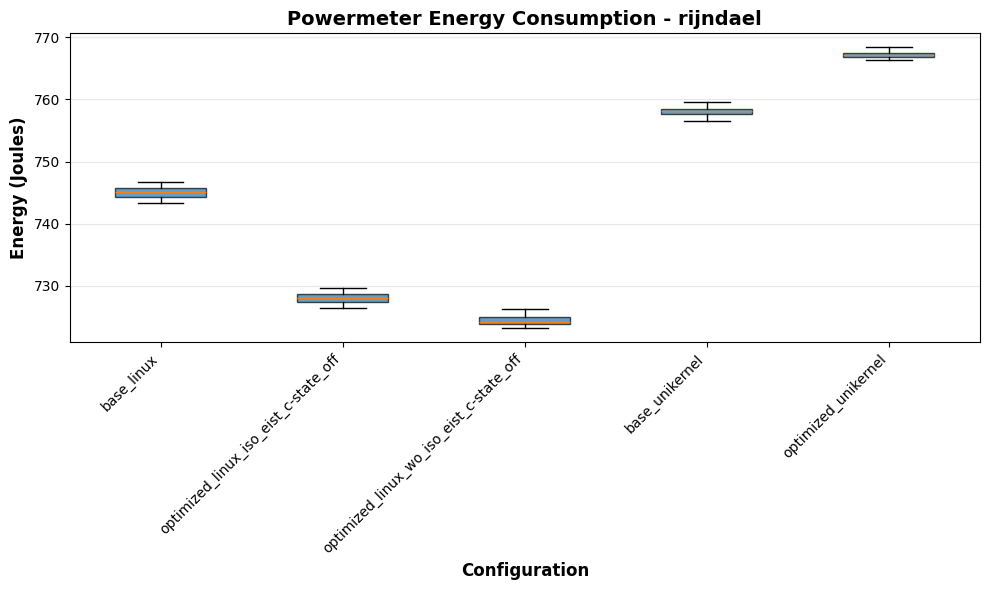

In [ ]:
# Boxplot for powermeter energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() ]
#configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        bench_data = []
        
        # Get powermeter data for this config and benchmark
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                timestamps = pd.to_numeric(pm_df['unix_timestamp'], errors='coerce').values
                time_span_s = (timestamps[-1] - timestamps[0]) / 1e6
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                bench_data.append(energy_j)
        
        if bench_data:
            data_to_plot.append(bench_data)
            labels.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            # patch.set_facecolor('lightcoral')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'Powermeter Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


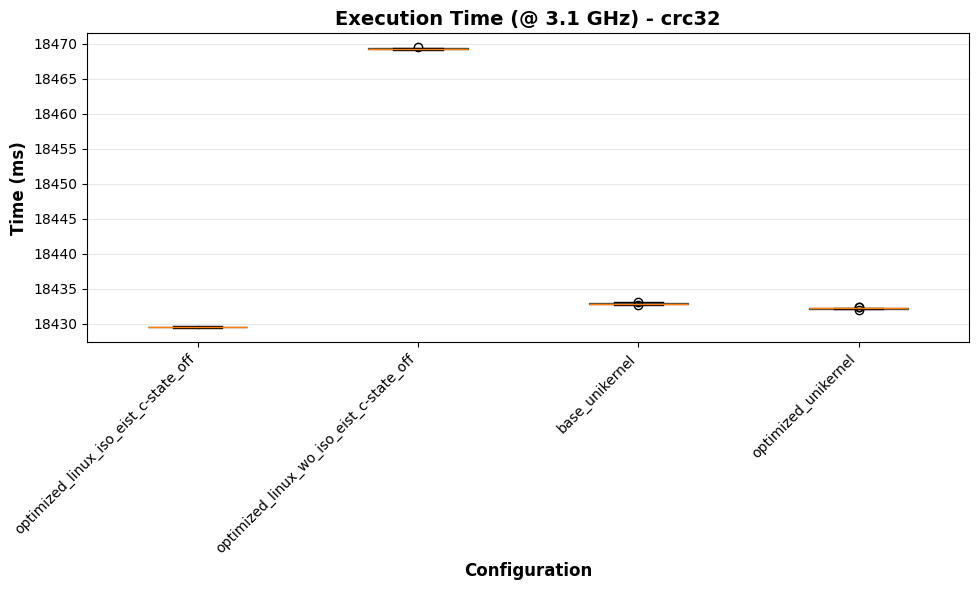

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


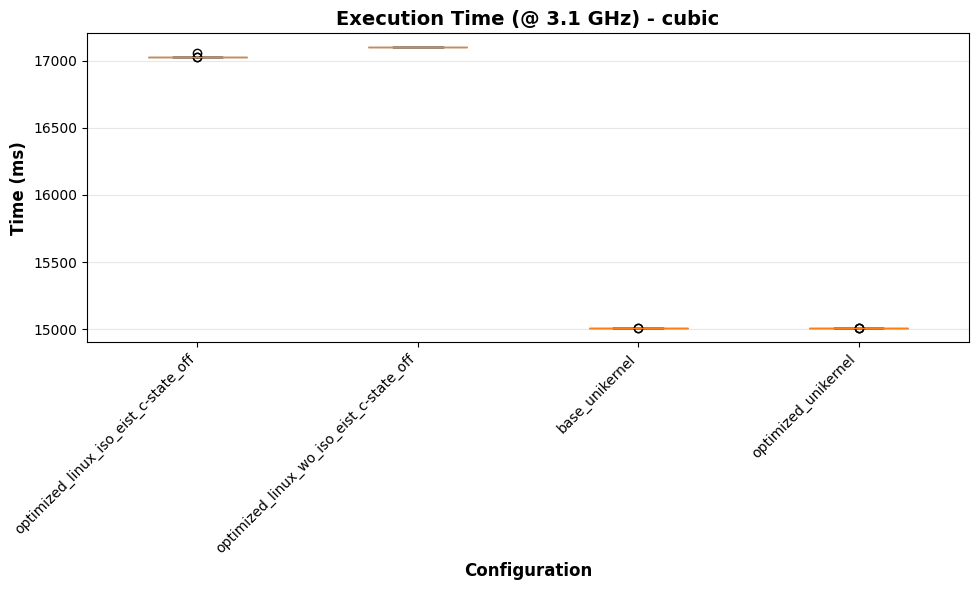

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


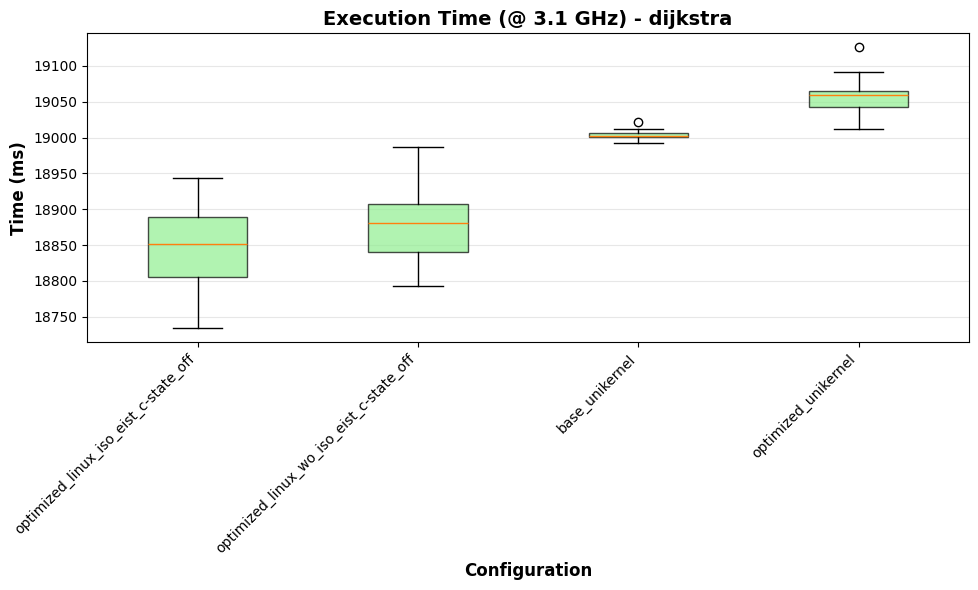

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


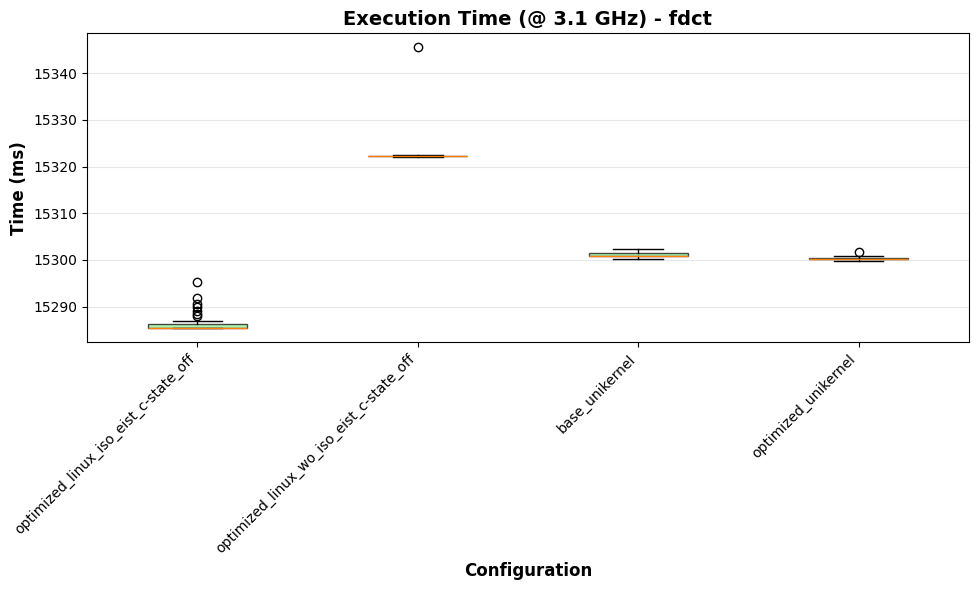

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


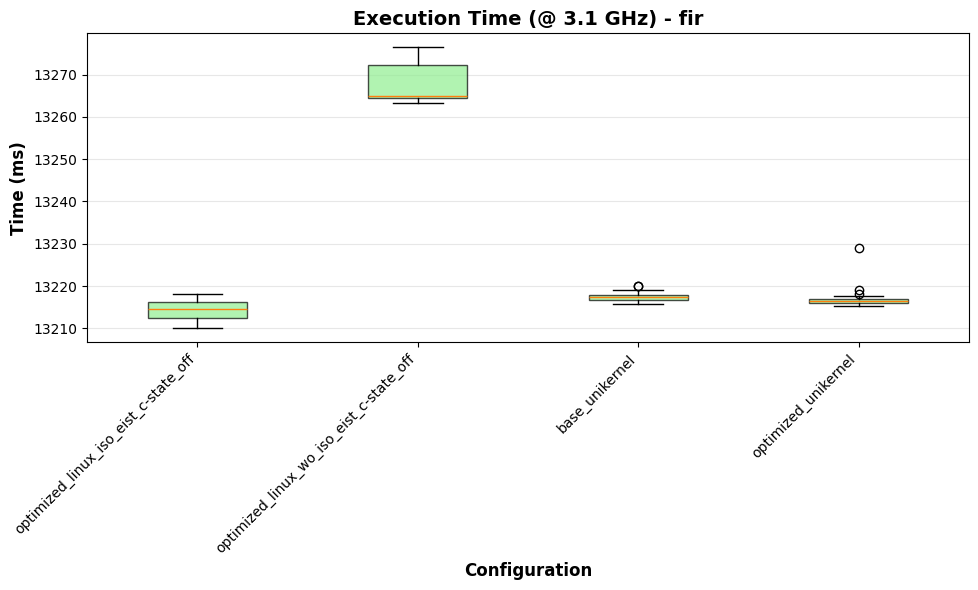

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


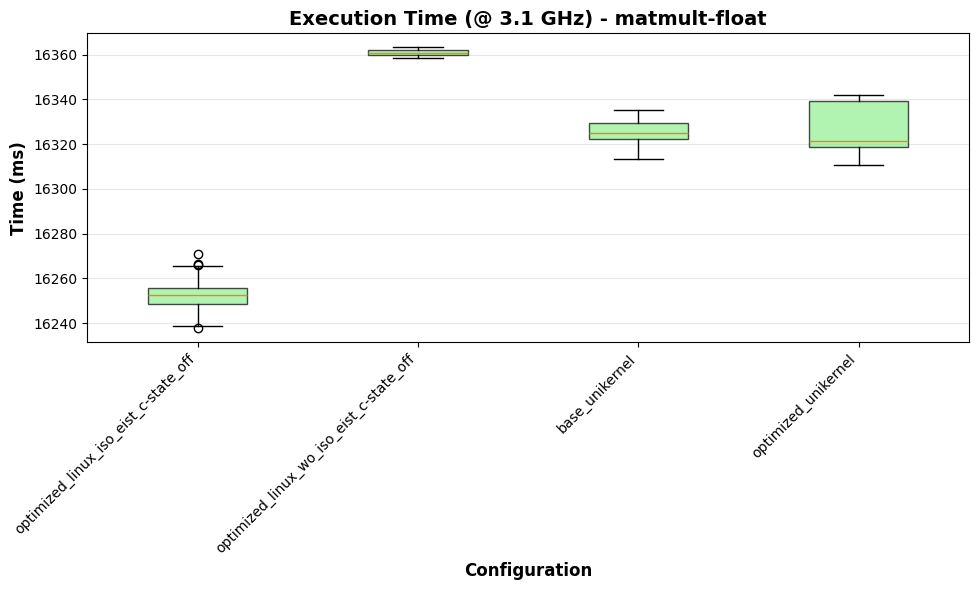

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


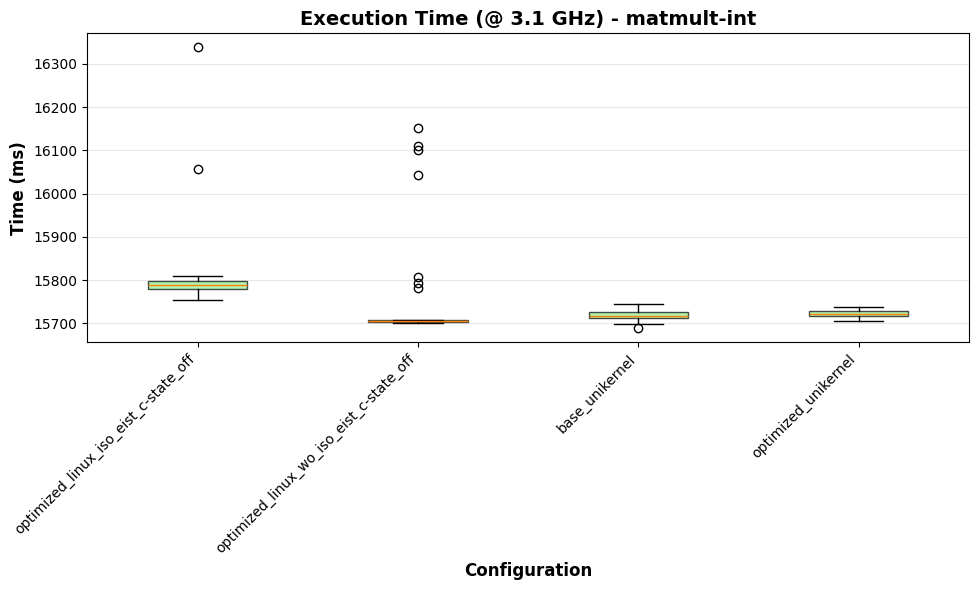

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


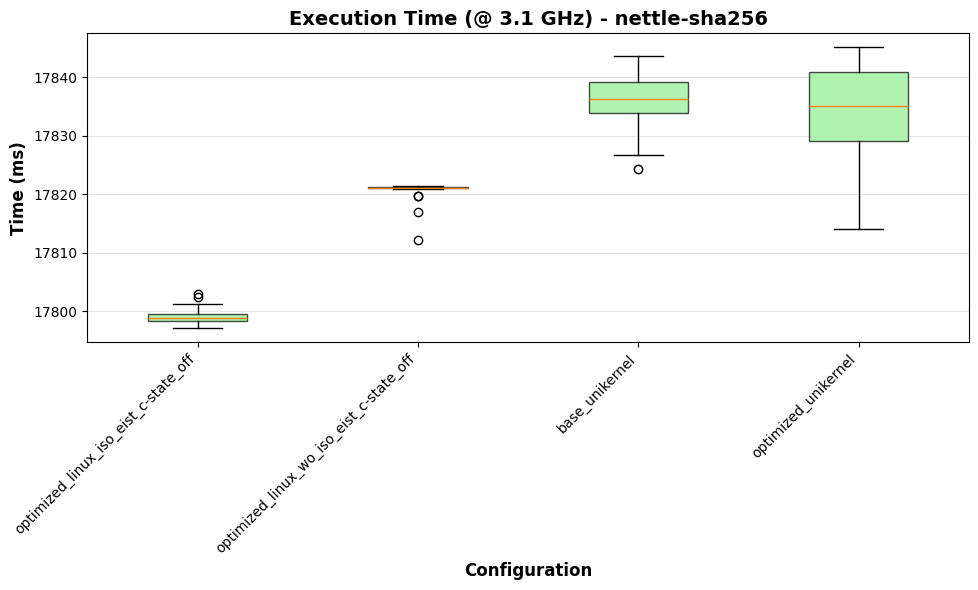

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2726041219.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


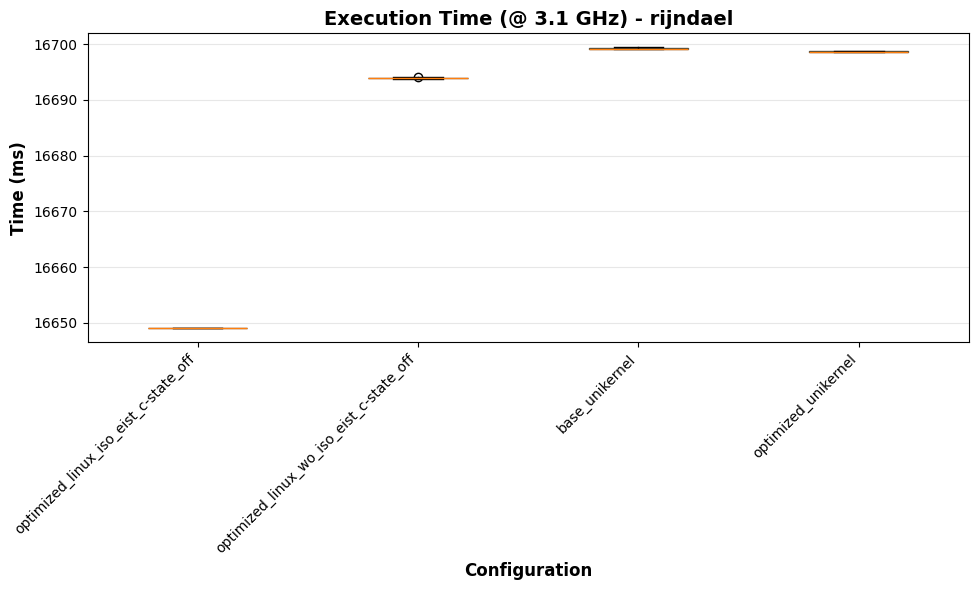

In [ ]:
# Boxplot for execution time per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    #'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            # Calculate time in ms from cpu_cycles using base frequency of 3.1 GHz
            # time (ms) = cycles / (3.1 × 10^9 Hz) × 1000 = cycles / 3.1e6
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            data_to_plot.append(time_ms)
            labels.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightgreen')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_title(f'Execution Time (@ 3.1 GHz) - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


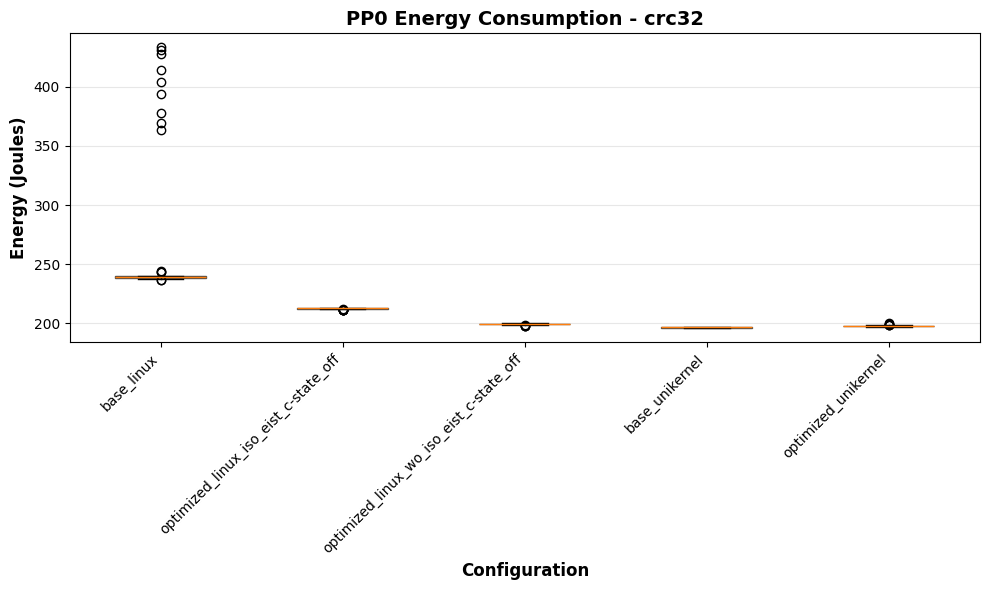

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


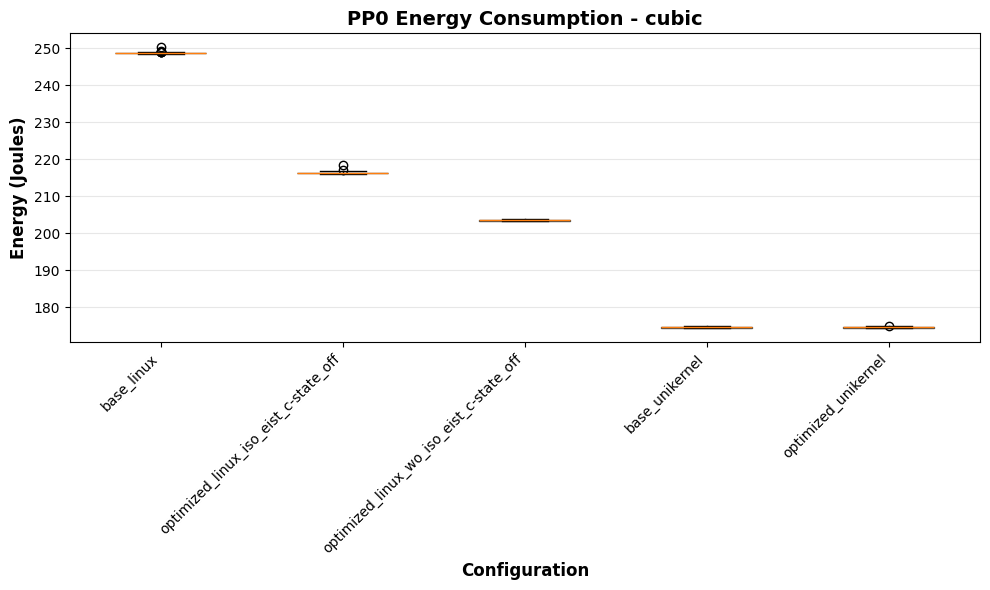

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


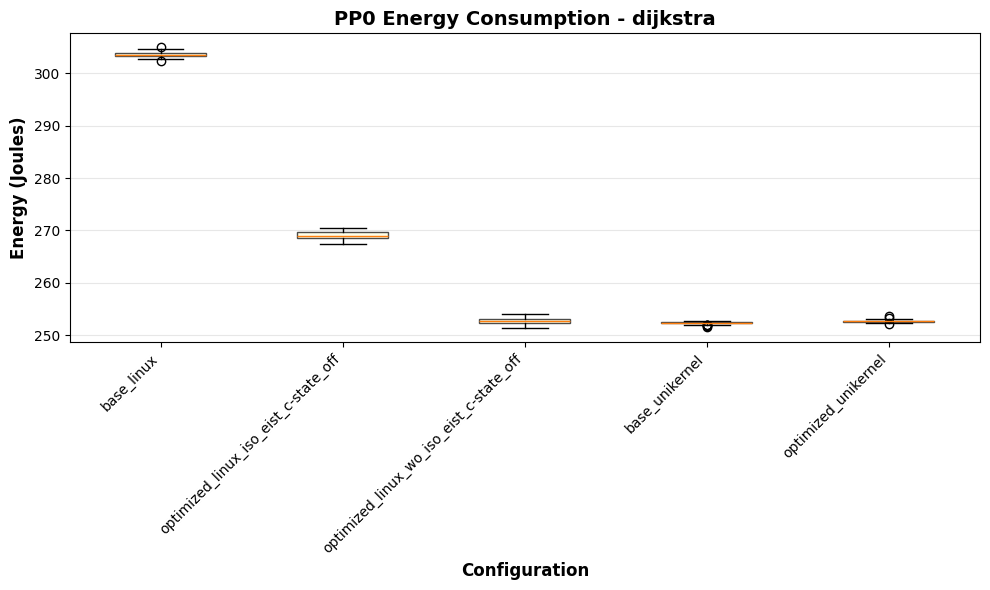

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


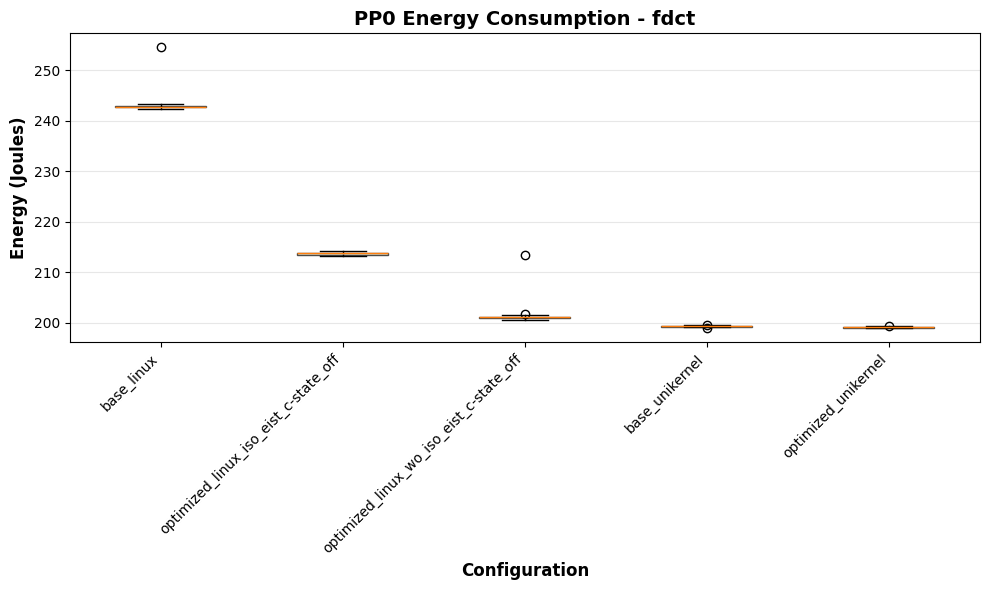

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


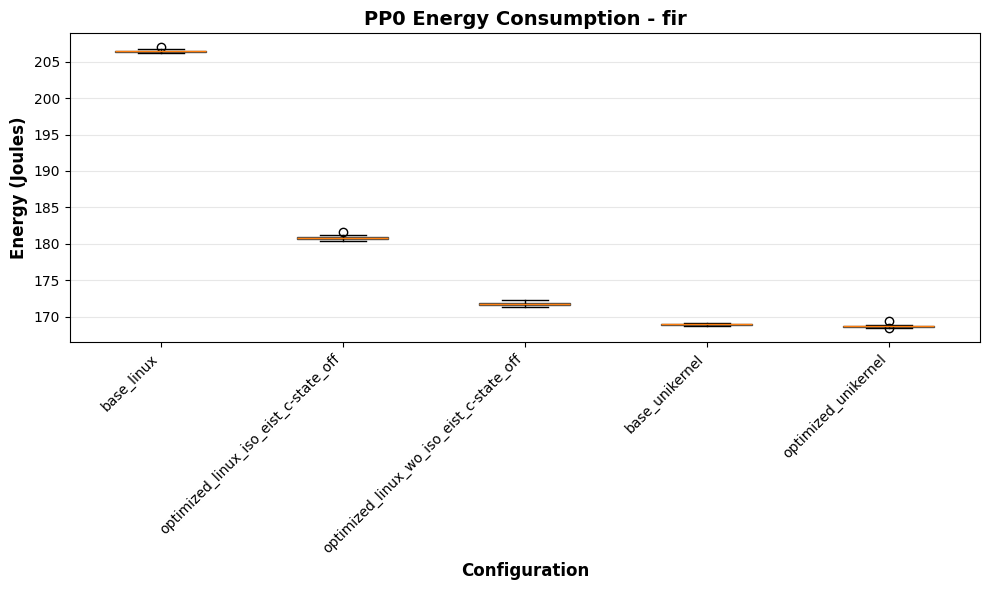

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


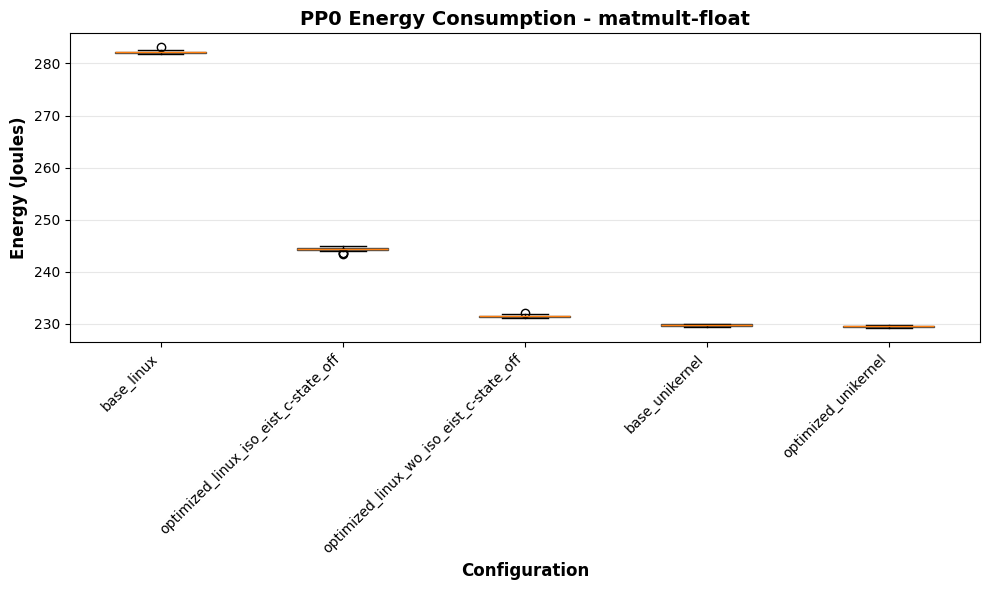

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


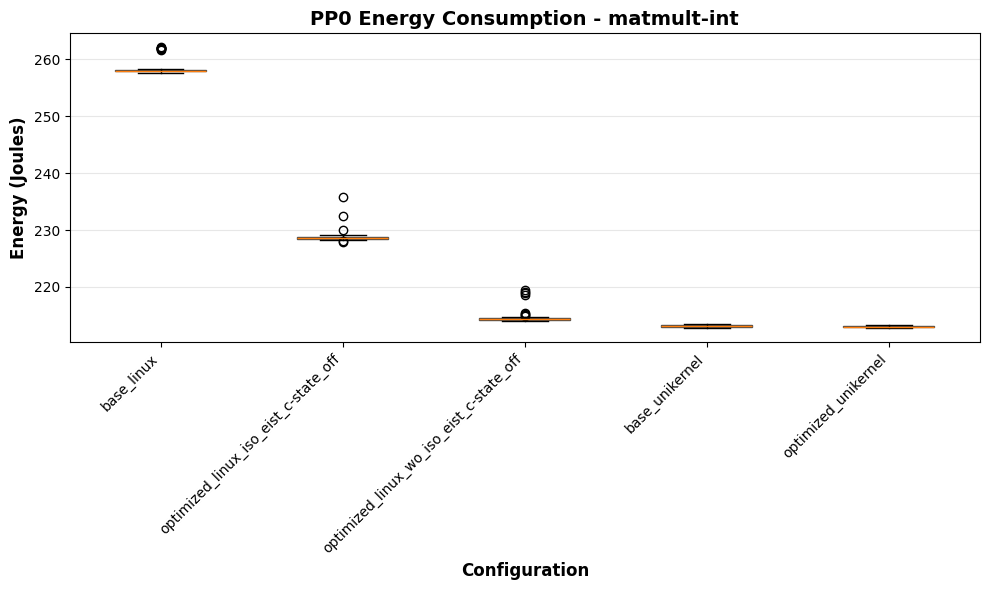

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


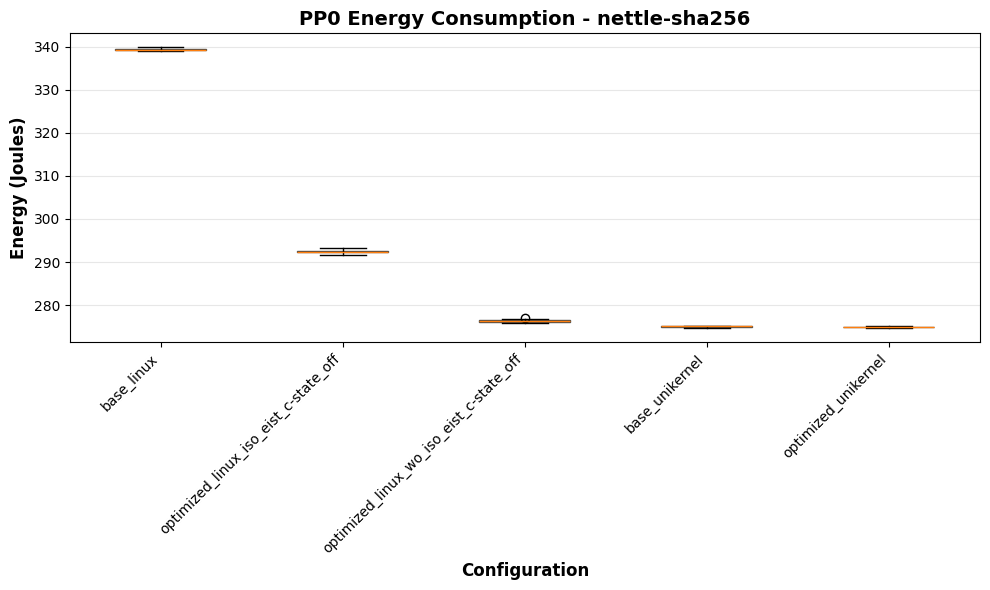

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74394/2425385170.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


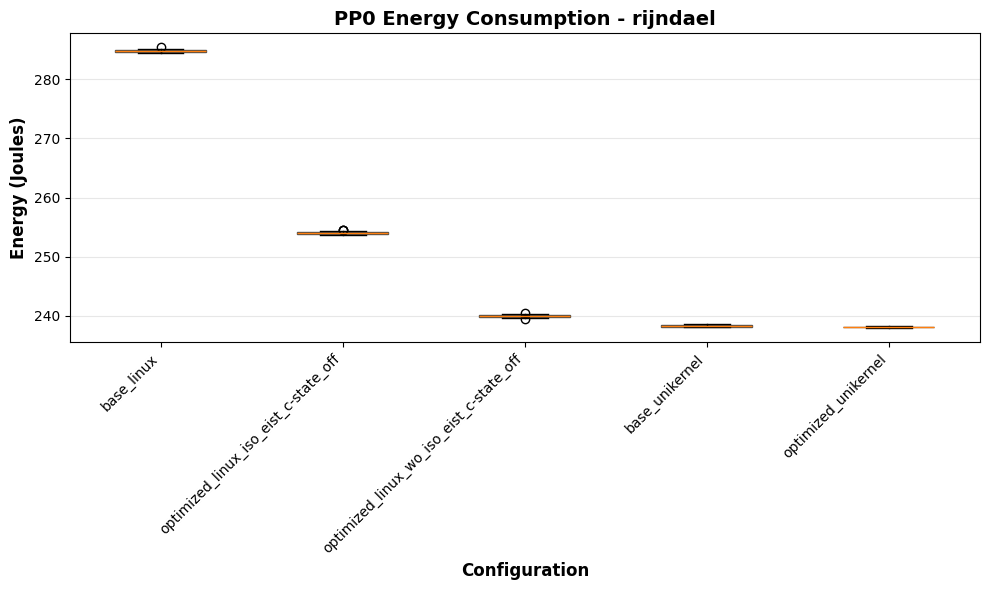

In [ ]:
# Boxplot for PP0 energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on'].copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pp0_joules'].values)
            labels.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightyellow')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PP0 Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [19]:
# Calculate total execution time for each configuration
print("Total execution time per configuration:")
print("=" * 60)

for config_name in subdirs.keys():
    if config_name not in pc_data:
        print(f"{config_name}: No data available")
        continue
    
    pc_df = pc_data[config_name]
    
    # Sum all execution times
    total_time_ms = pc_df['cooldown_ms'].sum()
    total_time_s = total_time_ms / 1000
    total_time_min = total_time_s / 60
    
    # Count number of measurements
    num_measurements = len(pc_df)
    
    print(f"\n{config_name}:")
    print(f"  Total time: {total_time_ms:,.2f} ms ({total_time_s:,.2f} s / {total_time_min:,.2f} min)")
    print(f"  Number of measurements: {num_measurements}")
    print(f"  Average time per measurement: {total_time_ms/num_measurements:.2f} ms")

Total execution time per configuration:

base_linux:
  Total time: 51,158.97 ms (51.16 s / 0.85 min)
  Number of measurements: 450
  Average time per measurement: 113.69 ms

base_unikernel:
  Total time: 4,600.00 ms (4.60 s / 0.08 min)
  Number of measurements: 450
  Average time per measurement: 10.22 ms

optimized_linux_iso_eist_c-state_off:
  Total time: 10,616.79 ms (10.62 s / 0.18 min)
  Number of measurements: 450
  Average time per measurement: 23.59 ms

optimized_linux_wo_iso_eist_c-state_off:
  Total time: 10,044.49 ms (10.04 s / 0.17 min)
  Number of measurements: 450
  Average time per measurement: 22.32 ms

optimized_linux_wo_iso_eist_c-state_on:
  Total time: 8,589.21 ms (8.59 s / 0.14 min)
  Number of measurements: 450
  Average time per measurement: 19.09 ms

optimized_unikernel:
  Total time: 4,100.00 ms (4.10 s / 0.07 min)
  Number of measurements: 451
  Average time per measurement: 9.09 ms
